# Employee Salary Prediction 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [4]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [5]:
df.describe(include ="object")

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [6]:
df.shape

(250000, 10)

In [7]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## EDA 

<Axes: ylabel='count'>

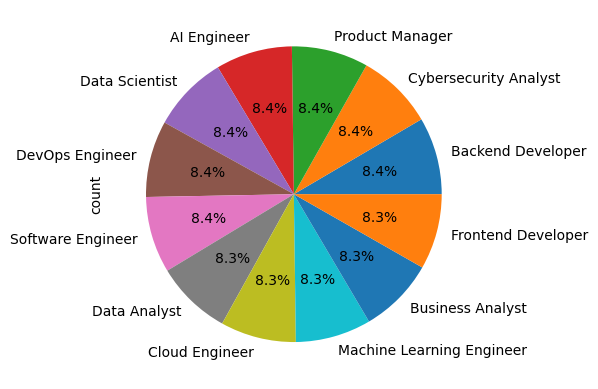

In [9]:
df['job_title'].value_counts().plot(kind = "pie", autopct='%1.1f%%')

<Axes: ylabel='count'>

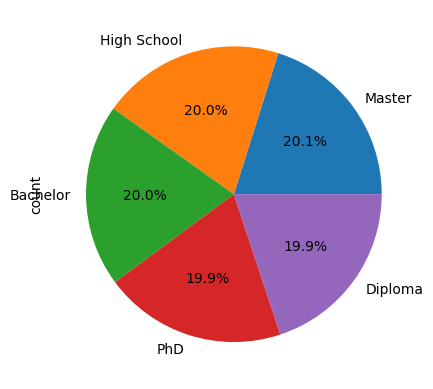

In [10]:
df['education_level'].value_counts().plot(kind = "pie", autopct='%1.1f%%')

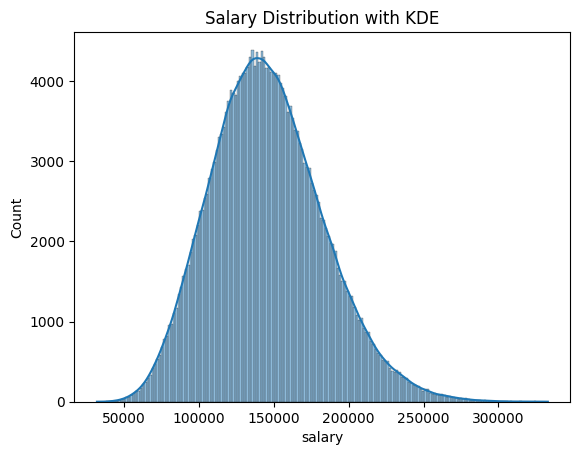

In [11]:
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution with KDE")
plt.show()

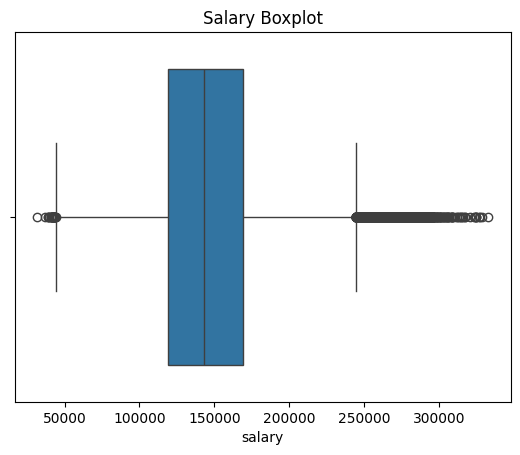

In [12]:
sns.boxplot(x=df['salary'])
plt.title("Salary Boxplot")
plt.show()

In [13]:
df['salary'].skew()

np.float64(0.3794009747285935)


Column: experience_years
Skewness: -0.0009517323628733443


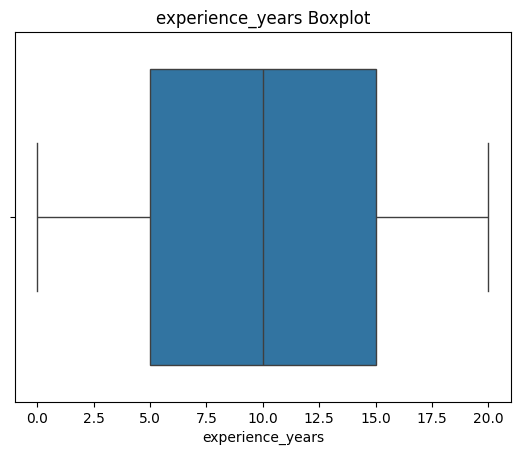


Column: skills_count
Skewness: 0.0003020025100380292


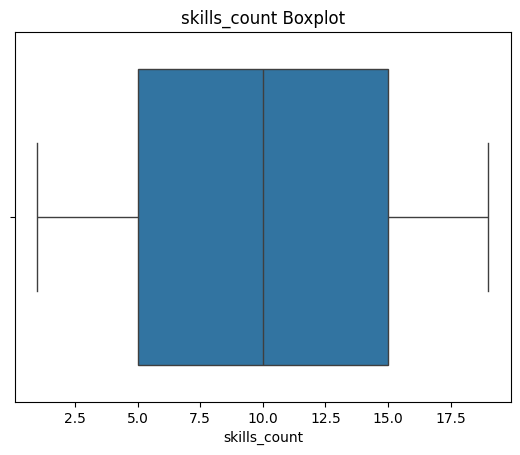


Column: certifications
Skewness: 0.003999892424639015


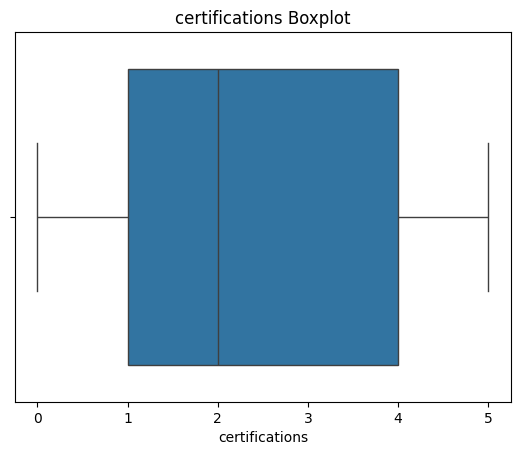


Column: salary
Skewness: 0.3794009747285935


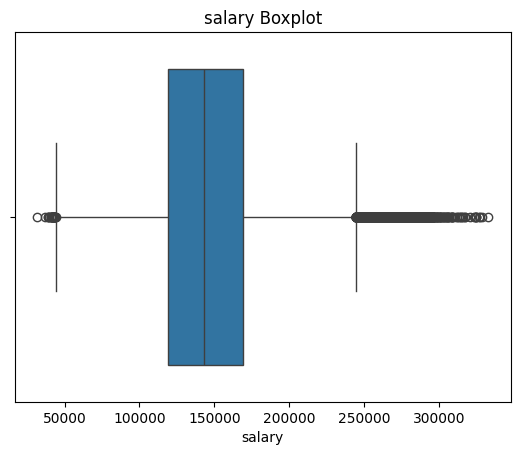

In [14]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    print(f"\nColumn: {col}")
    
    # Skewness
    print("Skewness:", df[col].skew())
    
    # Boxplot
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

<Axes: ylabel='count'>

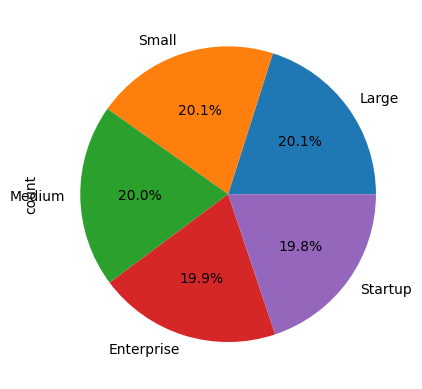

In [15]:
df['company_size'].value_counts().plot(kind = "pie", autopct='%1.1f%%')

<Axes: xlabel='count', ylabel='location'>

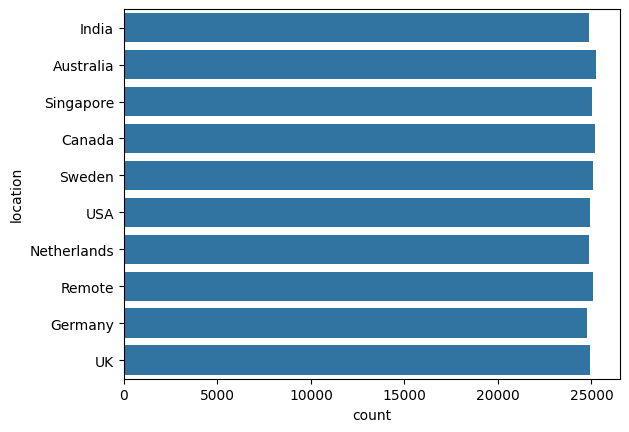

In [16]:
sns.countplot(df['location'])

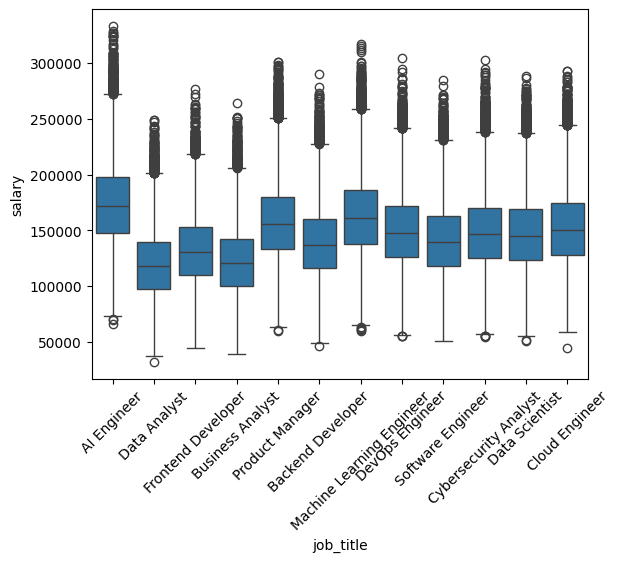

In [17]:
sns.boxplot(x='job_title', y='salary', data=df)
plt.xticks(rotation=45)
plt.show()

## DATA PREPROSESSING 

In [ ]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_trimmed = df[(df['salary'] >= lower) & (df['salary'] <= upper)]
df_trimmed = df

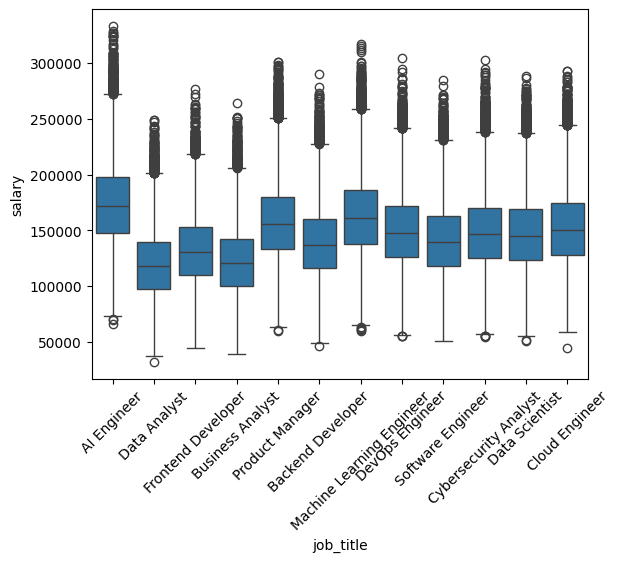

In [19]:
sns.boxplot(x='job_title', y='salary', data=df)
plt.xticks(rotation=45)
plt.show()

In [20]:
df['salary'].skew()

np.float64(0.3794009747285935)

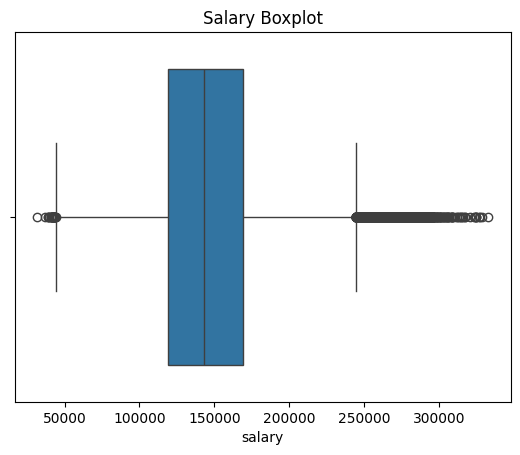

In [21]:
sns.boxplot(x=df['salary'])
plt.title("Salary Boxplot")
plt.show()

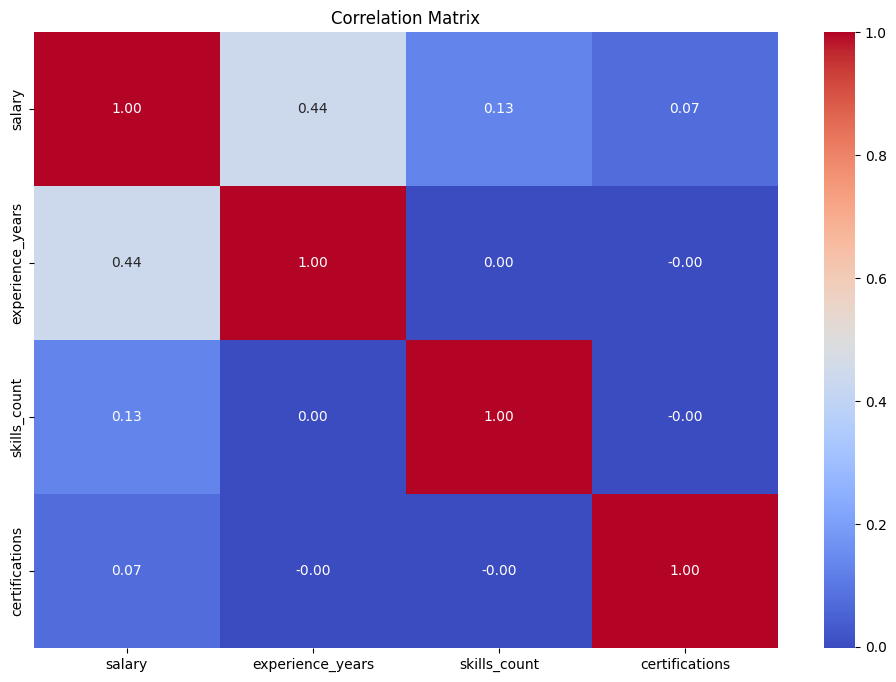

In [22]:
num_col = ['salary', 'experience_years', 'skills_count', 'certifications']
corr = df[num_col].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

In [23]:
df['salary'].kurtosis()

np.float64(0.15089558099594447)

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
numeric_features = ['salary', 'experience_years', 'skills_count', 'certifications']

df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [26]:
df = pd.get_dummies(df, columns=['industry', 'location', 'remote_work', 'job_title','education_level'], drop_first=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['company_size'] = le.fit_transform(df['company_size'])

In [27]:
df.head()

,experience_years,skills_count,company_size,certifications,salary,industry_Education,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,...,job_title_Data Scientist,job_title_DevOps Engineer,job_title_Frontend Developer,job_title_Machine Learning Engineer,job_title_Product Manager,job_title_Software Engineer,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD
0,-0.000892,-1.459647,2,-0.288272,-0.970520,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,-0.825894,1.277940,3,-1.460281,-1.388854,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.319111,-1.094636,2,-0.874276,0.064289,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,1.484112,0.547917,2,-1.460281,1.160315,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0.824110,-0.547118,1,-1.460281,0.517295,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False


In [28]:
df.shape

(250000, 40)

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
from sklearn.model_selection import train_test_split 
X = df.drop('salary', axis = 1)
y = df['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
X_train.shape


(200000, 39)

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
mse = mean_squared_error(y_test, y_pred)
mse

0.04130135512776388

In [35]:
rmse = np.sqrt(mse)

In [36]:
rmse

np.float64(0.20322734837556652)

In [37]:
r2 = r2_score(y_test, y_pred)
r2

0.9584167667838808

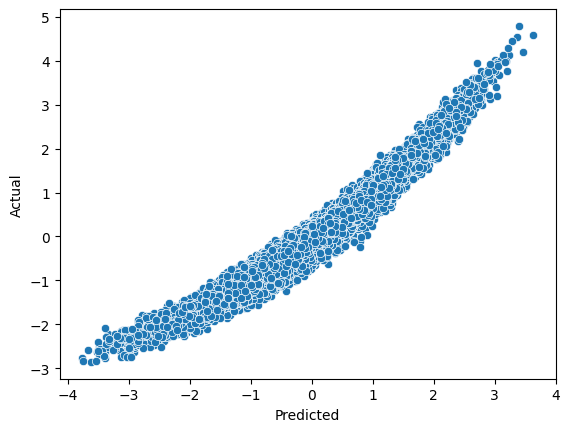

In [38]:
sns.scatterplot(x=y_pred, y=y_test)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
X = X.astype(float)

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Feature"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                                Feature       VIF
0                      experience_years  1.000128
1                          skills_count  1.000138
2                          company_size  2.840939
3                        certifications  1.000191
4                    industry_Education  1.726572
5                      industry_Finance  1.743294
6                   industry_Government  1.729743
7                   industry_Healthcare  1.731111
8                industry_Manufacturing  1.733849
9                        industry_Media  1.733217
10                      industry_Retail  1.726374
11                  industry_Technology  1.726158
12                     industry_Telecom  1.725713
13                      location_Canada  1.734367
14                     location_Germany  1.722848
15                       location_India  1.723670
16                 location_Netherlands  1.724368
17                      location_Remote  1.730399
18                   location_Singapore  1.727684


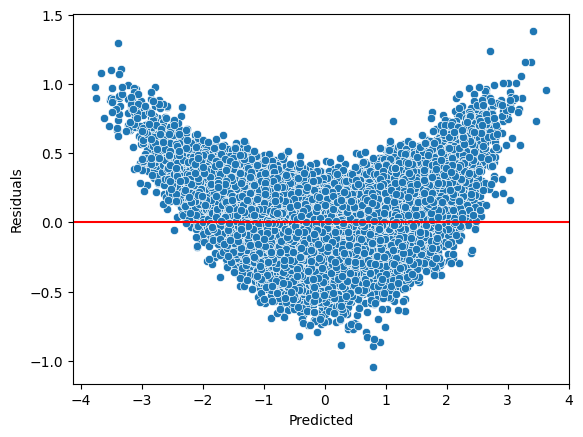

In [41]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

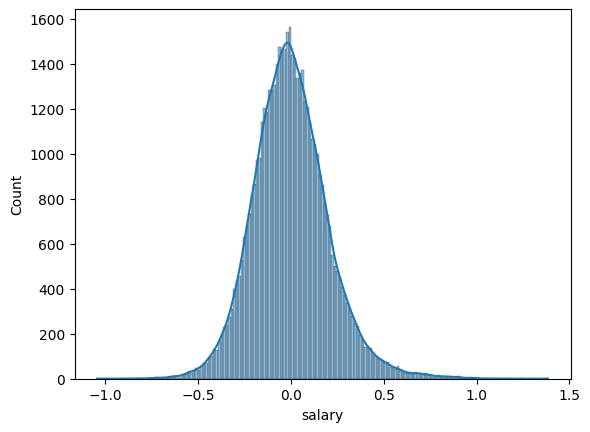

In [42]:
sns.histplot(residuals, kde=True)
plt.show()

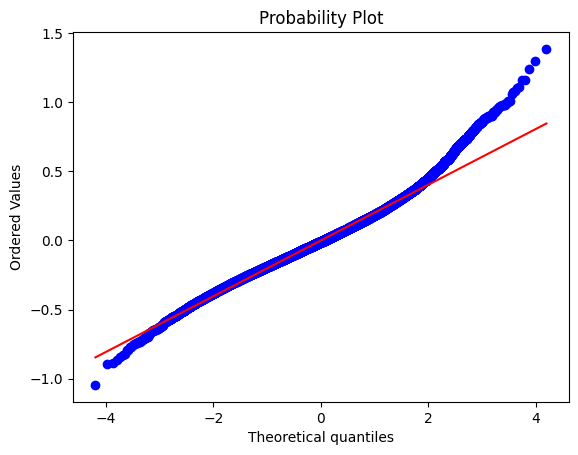

In [43]:
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

In [44]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson(residuals)

np.float64(2.0159797470287826)

In [45]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [48]:
y_pred = model.predict(X_test)

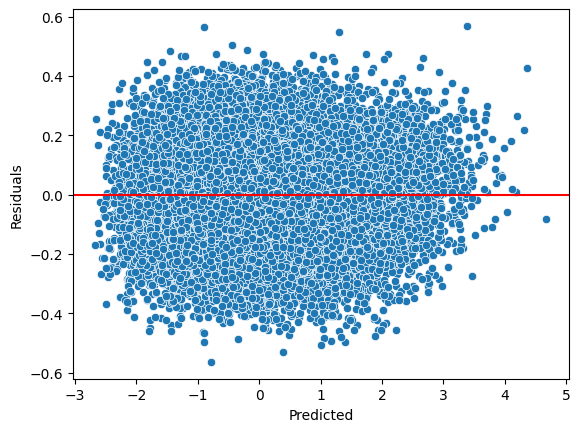

In [49]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
mse = mean_squared_error(y_test, y_pred)
mse

0.018599895343189784

In [52]:
rmse = np.sqrt(mse)

In [53]:
rmse

np.float64(0.1363814332788367)

In [54]:
R2 = r2_score(y_test, y_pred)

In [55]:
R2

0.9812731620195352

In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbours import KNearestNeighbours 

ModuleNotFoundError: No module named 'sklearn.neighbours'

In [57]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_rf = rf.predict(y_test)